<a href="https://colab.research.google.com/github/mihhwiNick/DA_project/blob/hau/us_baby_names.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Phân tích dữ liệu về tên trẻ sơ sinh ở Hoa Kì từ 1880 đến 2010

## 1 Định nghĩa vấn đề

Mô tả
* Phạm vi: Dữ liệu về tên trẻ em được đặt tại Hoa Kỳ từ năm 1880 đến 2010, được thu thập và công bố bởi Cơ quan An sinh Xã hội Hoa Kỳ (SSA).

* Kích thước: Gồm gần 1800000 bản ghi (mẫu), được tổng hợp từ các tệp hàng năm (mỗi năm một file).
* Đặc điểm: có 4 trường dữ liệu thông tin về tên và số lượng trẻ em

Dữ liệu vào
* name:	Tên trẻ em được đặt
* sex:	Giới tính của trẻ (M: Nam, F: Nữ)
* births: Số lượng trẻ sinh có tên đó trong năm
* year:	Năm sinh tương ứng

Dữ liệu ra (Kết quả phân tích):
* Các phát hiện về xu hướng đặt tên trẻ em tại Hoa Kỳ giai đoạn 1880–2010, dựa trên dữ liệu của Cơ quan An sinh Xã hội Mỹ (SSA).


Mục tiêu phân tích:

* Chuyên đề này được thực hiện nhằm đạt được các mục tiêu chính sau:

* Khám phá và trực quan hóa xu hướng đặt tên trẻ em theo giới tính qua các thời kỳ.

* Đánh giá mức độ phổ biến và sự đa dạng của tên gọi trong xã hội Mỹ theo thời gian.

* Phân tích đặc điểm ngôn ngữ trong cách đặt tên, tập trung vào chữ cái cuối và xu hướng phát âm.

* Nghiên cứu sự thay đổi trong việc sử dụng các tên trung tính giữa hai giới.



## 2 Chuẩn bị  xử lí

### 2.1 Khai báo thư viện

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


### 2.2 Nạp dữ liệu

In [ ]:
# kiểm tra file
names1880 = pd.read_csv("/content/drive/MyDrive/ptdl/tuan6/babynames/yob1880.txt",names=["name", "sex", "births"])


In [ ]:
names1880

,name,sex,births
0,Mary,F,7065
1,Anna,F,2604
2,Emma,F,2003
3,Elizabeth,F,1939
4,Minnie,F,1746
...,...,...,...
1995,Woodie,M,5
1996,Worthy,M,5
1997,Wright,M,5
1998,York,M,5


In [ ]:
# tổng số ca sinh trong năm 1880 theo giới tính
names1880.groupby("sex")["births"].sum()

,births
sex,
F,90993
M,110493


In [ ]:
# tập hợp dữ liệu vào dataframe duy nhất và thêm cột 'year'
pieces = []
for year in range(1880, 2011):
 path = f"/content/drive/MyDrive/ptdl/tuan6/babynames/yob{year}.txt"
 frame = pd.read_csv(path, names=["name", "sex", "births"])
 # Add a column for the year
 frame["year"] = year
 pieces.append(frame)
# Concatenate everything into a single DataFrame
names = pd.concat(pieces, ignore_index=True)


In [ ]:
names

,name,sex,births,year
0,Mary,F,7065,1880
1,Anna,F,2604,1880
2,Emma,F,2003,1880
3,Elizabeth,F,1939,1880
4,Minnie,F,1746,1880
...,...,...,...,...
1690779,Zymaire,M,5,2010
1690780,Zyonne,M,5,2010
1690781,Zyquarius,M,5,2010
1690782,Zyran,M,5,2010


### 2.3 Thông tin tổng quát về dữ liệu

In [ ]:
names.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1690784 entries, 0 to 1690783
Data columns (total 4 columns):
 #   Column  Non-Null Count    Dtype 
---  ------  --------------    ----- 
 0   name    1690784 non-null  object
 1   sex     1690784 non-null  object
 2   births  1690784 non-null  int64 
 3   year    1690784 non-null  int64 
dtypes: int64(2), object(2)
memory usage: 51.6+ MB


Thông tin cơ bản của bộ dữ liệu

* Dữ liệu có 4 tính chất (cột) để phân tích, bao gồm:
name, sex, births, và year.

* Các giá trị gồm 2 cột kiểu object (name, sex) và 2 cột kiểu int64 (births, year).

* Tổng số dòng dữ liệu là 1,690,784 bản ghi, tương ứng với số lượng tên được thống kê từ năm 1880 đến năm 2010.

Bộ dữ liệu này không có cột phân lớp, mà mang tính thống kê mô tả. Trong đó, biến chính để phân tích là births - biểu thị số trẻ sinh mang tên cụ thể trong từng năm và giới tính.

## 3 EDA và trực quan hóa

### Câu hỏi: sự thay đổi về tổng số trẻ sinh theo giới tính qua các giai đoạn (1880–2010) là như thế nào?

In [ ]:
# tập hợp dữ liệu theo năm và giới tính bằng pivot
total_births = names.pivot_table("births", index="year", columns="sex", aggfunc=sum)
total_births.head()

/tmp/ipython-input-754181333.py:2: FutureWarning: The provided callable <built-in function sum> is currently using DataFrameGroupBy.sum. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "sum" instead.
  total_births = names.pivot_table("births", index="year", columns="sex", aggfunc=sum)


sex,F,M
year,,
1880,90993,110493
1881,91955,100748
1882,107851,113687
1883,112322,104632
1884,129021,114445


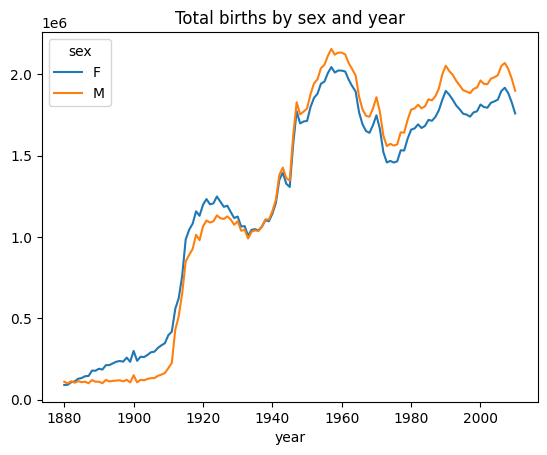

In [ ]:
total_births.plot(title="Total births by sex and year")
plt.savefig("total_births.png")


Nhận xét:
* Giai đoạn 1880–1930:

    * Số lượng trẻ nữ sinh ra cao hơn trẻ nam, thể hiện qua đường biểu diễn của giới nữ nằm trên giới nam.

    * Điều này có thể phản ánh tỷ lệ khai sinh hoặc ghi nhận tên nữ được thống kê nhiều hơn trong giai đoạn đầu.
* Giai đoạn 1930–1950:

    * Hai đường biểu diễn gần như trùng nhau, cho thấy số lượng trẻ nam và nữ sinh ra gần bằng nhau.

    * Đây có thể là giai đoạn dữ liệu trở nên ổn định và đồng đều hơn, phản ánh sự chuẩn hóa trong thống kê hoặc tỷ lệ giới tính tự nhiên.

* Giai đoạn 1950–2010:

    * Số lượng trẻ nam sinh ra nhiều hơn nữ, thể hiện rõ qua việc đường biểu diễn của nam vượt lên trên.


### Sau khi đã quan sát sự thay đổi về tổng số trẻ sinh theo giới tính qua các giai đoạn (1880–2010), ta tiếp tục đi sâu vào xu hướng đặt tên cụ thể của người dân Mỹ.

Mục tiêu:
Xác định xem mức độ phổ biến của một số tên tiêu biểu (như John, Harry, Mary, Marilyn) có thay đổi theo thời gian hay không. Liệu những cái tên từng “thống trị” bảng xếp hạng đặt tên ở thế kỷ 19 có còn được ưa chuộng ở thế kỷ 21?

Các bước xử lí dữ liệu:

Bước 1: tính tỉ lệ sinh

In [ ]:
# tỷ lệ sinh của mỗi tên so với tổng số ca sinh trong năm và giới tính đó.

def add_prop(group):
  group["prop"] = group["births"] / group["births"].sum()
  return group
names = names.groupby(["year", "sex"], group_keys=False).apply(add_prop).reset_index()


/tmp/ipython-input-539826342.py:6: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  names = names.groupby(["year", "sex"], group_keys=False).apply(add_prop).reset_index()


In [ ]:
names

,index,name,sex,births,year,prop
0,0,Mary,F,7065,1880,0.077643
1,1,Anna,F,2604,1880,0.028618
2,2,Emma,F,2003,1880,0.022013
3,3,Elizabeth,F,1939,1880,0.021309
4,4,Minnie,F,1746,1880,0.019188
...,...,...,...,...,...,...
1690779,1690779,Zymaire,M,5,2010,0.000003
1690780,1690780,Zyonne,M,5,2010,0.000003
1690781,1690781,Zyquarius,M,5,2010,0.000003
1690782,1690782,Zyran,M,5,2010,0.000003


In [ ]:
# xác minh tổng prop là 1 trong tất cả các nhóm
names.groupby(["year", "sex"])["prop"].sum()

year  sex
1880  F      1.0
      M      1.0
1881  F      1.0
      M      1.0
1882  F      1.0
            ... 
2008  M      1.0
2009  F      1.0
      M      1.0
2010  F      1.0
      M      1.0
Name: prop, Length: 262, dtype: float64

Bước 2: Tiến hành lấy ra 1000 dòng dữ liệu đầu tiên theo giới tính và năm sinh

Mục tiêu là tập trung vào nhóm tên có ảnh hưởng lớn nhất đến xu hướng chung, loại bỏ nhiễu từ các tên hiếm gặp.

In [ ]:
# 1000 tên hàng đầu cho mỗi cặp giới tính/năm

top1000 = names.groupby(["year", "sex"]).apply(lambda x: x.head(1000))
top1000 = top1000.reset_index(drop=True)

/tmp/ipython-input-2674805285.py:3: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  top1000 = names.groupby(["year", "sex"]).apply(lambda x: x.head(1000))


In [ ]:
# bỏ chỉ số nhóm vì không cần cho việc phân tích
top1000 = top1000.reset_index(drop=True)
top1000.head()


,index,name,sex,births,year,prop
0,0,Mary,F,7065,1880,0.077643
1,1,Anna,F,2604,1880,0.028618
2,2,Emma,F,2003,1880,0.022013
3,3,Elizabeth,F,1939,1880,0.021309
4,4,Minnie,F,1746,1880,0.019188


In [ ]:
# tổng số ca sinh theo năm và tên
total_births = top1000.pivot_table("births", index="year",
columns="name",
aggfunc=sum)

/tmp/ipython-input-2690042770.py:2: FutureWarning: The provided callable <built-in function sum> is currently using DataFrameGroupBy.sum. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "sum" instead.
  total_births = top1000.pivot_table("births", index="year",


In [ ]:
total_births.info()


<class 'pandas.core.frame.DataFrame'>
Index: 131 entries, 1880 to 2010
Columns: 6862 entries, Aaden to Zuri
dtypes: float64(6862)
memory usage: 6.9 MB


Nhận xét:Dữ liệu total_births là một DataFrame dạng bảng tổng hợp (pivot table) với:

* Chỉ số (Index): 131 giá trị tương ứng với các năm từ 1880 đến 2010 → thể hiện theo dõi liên tục qua từng năm.

* Số cột (Columns): 6.862 tên, từ “Aaden” đến “Zuri”, biểu diễn các tên trẻ em được ghi nhận trong dữ liệu.

* Kiểu dữ liệu: float64 cho toàn bộ các cột → do có thể có giá trị NaN (thiếu dữ liệu) khi một tên không xuất hiện trong năm nào đó.

* Dung lượng bộ nhớ: ~6.9 MB, cho thấy đây là một tập dữ liệu khá lớn, phản ánh xu hướng đặt tên qua hơn một thế kỷ.

Bước 3: Tổng hợp và trực quan hóa dữ liệu

In [ ]:
# Chọn những tên có phần trăm xuất hiện cao
subset = total_births[["John", "Harry", "Mary", "Marilyn"]]


<Figure size 640x480 with 0 Axes>

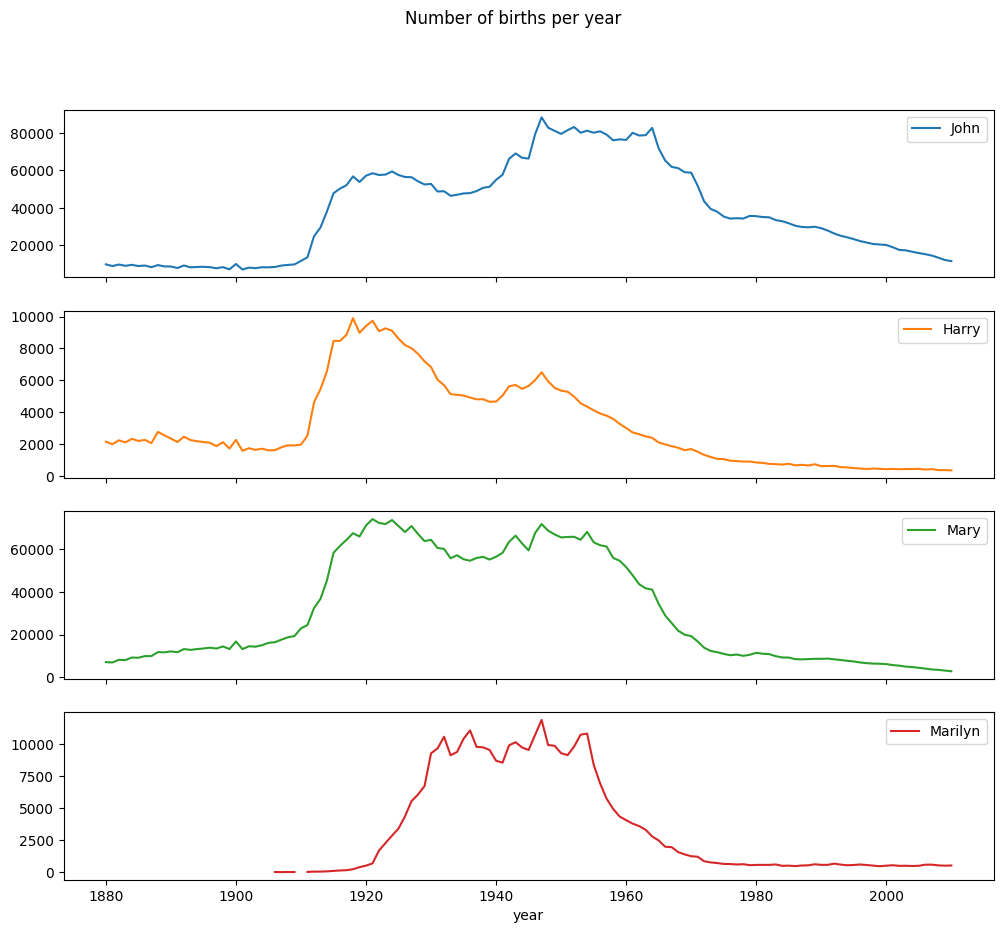

In [ ]:
subset.plot(subplots=True, figsize=(12, 10), title="Number of births per year")
plt.savefig("births.png")

Khi quan sát biểu đồ số lượng trẻ được đặt tên John, Harry, Mary, Marilyn theo thời gian, ta nhận thấy:

* Tất cả các tên này đều có mức độ phổ biến cao trong khoảng từ 1900 đến 1980, nhưng đều giảm mạnh sau năm 1980.

* Một số tên như Mary từng là tên phổ biến nhất trong nhiều thập kỷ, nhưng dần mất đi vị thế trong những năm gần đây.
Kết luận (vì sao lại như vậy):

Xu hướng giảm dần này phản ánh sự thay đổi trong thị hiếu và văn hóa đặt tên của người Mỹ:

* Những cái tên này không còn được ưa chuộng nữa, ít cha mẹ chọn tên phổ biến cho con cái.
* Sự thay đổi này phản ánh thị hiếu đặt tên chuyển dịch theo thời gian, chịu ảnh hưởng bởi xu hướng văn hóa, xã hội và truyền thông (ví dụ: tên diễn viên, nhân vật nổi tiếng, hoặc trào lưu từng thời kỳ).
* Nói cách khác, việc đặt tên đã bớt truyền thống hơn và trở nên linh hoạt, cá nhân hóa hơn.

### Tuy nhiên, việc giảm phổ biến của một số tên riêng lẻ chưa đủ để phản ánh toàn bộ xu hướng xã hội.
Do đó, ta tiếp tục đi sâu hơn để phân tích mức độ đa dạng hóa trong đặt tên qua thời gian.

Câu hỏi đặt ra:

Người Mỹ có đang đặt tên cho con ngày càng đa dạng hơn không?
Hay vẫn tập trung quanh một số tên phổ biến nhất?

/tmp/ipython-input-3895888949.py:2: FutureWarning: The provided callable <built-in function sum> is currently using DataFrameGroupBy.sum. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "sum" instead.
  table = top1000.pivot_table("prop", index="year", columns="sex", aggfunc=sum)


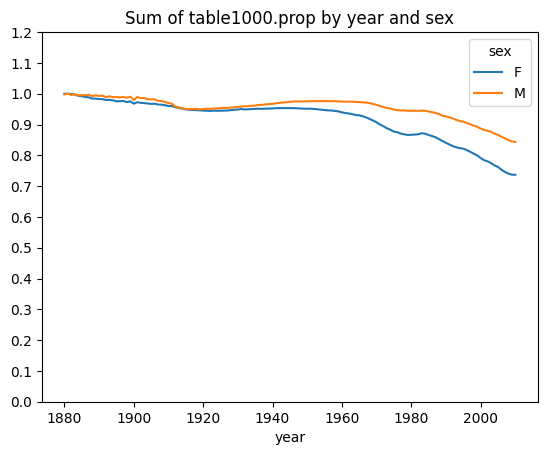

In [ ]:
# tỉ lệ sinh đại diện bởi 1000 tên phổ biến, theo năm và giới tính
table = top1000.pivot_table("prop", index="year", columns="sex", aggfunc=sum)
table.plot(title="Sum of table1000.prop by year and sex", yticks=np.linspace(0, 1.2, 13))
plt.savefig("top1000.png")

Nhận xét:

* Kết quả cho thấy cả hai giới tính đều có xu hướng giảm dần rõ rệt từ năm 1880 đến 2010.

-> Mức độ tập trung vào các tên phổ biến ngày càng giảm, hay nói cách khác, người dân có xu hướng đặt tên đa dạng hơn cho con cái — phản ánh sự thay đổi trong văn hóa và cá tính hóa lựa chọn tên.

Tiếp theo, ta xác định xem cần bao nhiêu tên phổ biến nhất để chiếm 50% tổng số ca sinh trong một năm nhất định.

In [ ]:
boys = top1000[top1000["sex"] == "M"]
girls = top1000[top1000["sex"] == "F"]


In [ ]:
# số lượng tên con trai từ năm 2010, được sắp xếp theo thứ tự phổ biến từ cao đến thấp
df = boys[boys["year"] == 2010]
df

,index,name,sex,births,year,prop
260877,1676644,Jacob,M,21875,2010,0.011523
260878,1676645,Ethan,M,17866,2010,0.009411
260879,1676646,Michael,M,17133,2010,0.009025
260880,1676647,Jayden,M,17030,2010,0.008971
260881,1676648,William,M,16870,2010,0.008887
...,...,...,...,...,...,...
261872,1677639,Camilo,M,194,2010,0.000102
261873,1677640,Destin,M,194,2010,0.000102
261874,1677641,Jaquan,M,194,2010,0.000102
261875,1677642,Jaydan,M,194,2010,0.000102


Sắp xếp tỉ lệ sinh giảm dần

In [ ]:
prop_cumsum = df["prop"].sort_values(ascending=False).cumsum()
prop_cumsum[:10]

,prop
260877,0.011523
260878,0.020934
260879,0.029959
260880,0.038930
260881,0.047817
260882,0.056579
260883,0.065155
260884,0.073414
260885,0.081528
260886,0.089621


Trong năm 2010, cần bao nhiêu tên con trai phổ biến nhất để chiếm một nửa tổng số ca sinh?

In [ ]:
prop_cumsum.searchsorted(0.5)

np.int64(116)

Nhận xét:
* Vì mảng có index = 0, nên cần cộng thêm 1 vào kết quả cuối cùng. Vì vậy cần 117 người có tên phổ biến nhất để đạt 50%

Tiếp theo, tiến hành so sánh với tổng số con trai có tên phổ biến nhất để tỉ lệ sinh đạt 50% vào năm 1900

In [ ]:
df = boys[boys.year == 1900]
in1900 = df.sort_values("prop", ascending=False).prop.cumsum()
in1900.searchsorted(0.5) + 1

np.int64(25)

Nhận xét:
* Vào năm 1900, chỉ cần 25 tên phổ biến nhất đã chiếm tới 50% tổng số ca sinh, trong khi vào năm 2010 con số này là 117 tên.

-> Trong vòng hơn một thế kỷ, mức độ đa dạng trong việc đặt tên đã tăng gần 5 lần.

Tiếp theo, ta đo lường xu hướng đa dạng theo giới tính và thời gian - Liệu xu hướng đa dạng hóa tên gọi có khác nhau giữa con trai và con gái không?

In [ ]:
def get_quantile_count(group, q=0.5):
 group = group.sort_values("prop", ascending=False)
 return group.prop.cumsum().searchsorted(q) + 1
diversity = top1000.groupby(["year", "sex"]).apply(get_quantile_count)
diversity = diversity.unstack()

/tmp/ipython-input-3455365967.py:4: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  diversity = top1000.groupby(["year", "sex"]).apply(get_quantile_count)


In [ ]:
diversity.head()

sex,F,M
year,,
1880,38,14
1881,38,14
1882,38,15
1883,39,15
1884,39,16


Biểu đồ tổng số người để tỉ lệ sinh đạt 50%

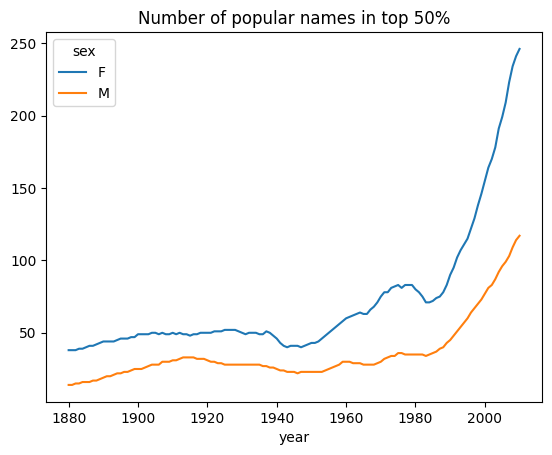

In [ ]:
diversity.plot(title="Number of popular names in top 50%")
plt.savefig("diversity.png")

Nhận xét:
* Biểu đồ cho thấy tên của con gái luôn đa dạng hơn tên con trai, và xu hướng này ngày càng rõ rệt theo thời gian.

Kết luận:
* Văn hoá đặt tên cho con gái thường chịu ảnh hưởng của thời trang, truyền thông và các trào lưu xã hội, dẫn đến sự thay đổi tên nhanh chóng (ví dụ: tên diễn viên, ca sĩ, nhân vật nổi tiếng).

* Ngược lại, tên con trai có xu hướng ổn định hơn, do truyền thống gia đình hoặc các giá trị bảo thủ về giới tính.

* Xu hướng gia tăng mức độ đa dạng tên phản ánh sự cá nhân hóa và tự do lựa chọn trong xã hội Mỹ hiện đại, khi cha mẹ muốn con mình có tên “độc đáo” hơn thay vì theo khuôn mẫu truyền thống.

###  Sau khi đã quan sát sự thay đổi về tổng số trẻ sinh theo giới tính qua các giai đoạn (1880–2010) và sự đa dạng trong việc đặt tên, ta tiếp tục đi sâu hơn vào một khía cạnh thú vị: sự thay đổi trong chữ cái cuối cùng của tên qua thời gian.

Liệu chữ cái cuối của tên trẻ có phản ánh sự thay đổi trong xu hướng đặt tên qua các thời kỳ hay không?
Cụ thể, những chữ cái nào trở nên phổ biến hoặc giảm dần trong các thế hệ?

Trước hết, ta tổng hợp số ca sinh theo năm, giới tính và chữ cái cuối trong tên:

In [ ]:
def get_last_letter(x):
 return x[-1]
last_letters = names["name"].map(get_last_letter)
last_letters.name = "last_letter"


In [ ]:
table = names.pivot_table("births", index=last_letters,
 columns=["sex", "year"], aggfunc=sum)

/tmp/ipython-input-828021911.py:1: FutureWarning: The provided callable <built-in function sum> is currently using DataFrameGroupBy.sum. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "sum" instead.
  table = names.pivot_table("births", index=last_letters,


Sau đó, chọn ba năm đại diện trong tập dữ liệu: 1910, 1960 và 2010 – tương ứng với ba giai đoạn cách nhau khoảng 50 năm.

In [ ]:
subtable = table.reindex(columns=[1910, 1960, 2010], level="year")
subtable.head()

sex                 F                            M                    
year             1910      1960      2010     1910      1960      2010
last_letter                                                           
a            108376.0  691247.0  670605.0    977.0    5204.0   28438.0
b                 NaN     694.0     450.0    411.0    3912.0   38859.0
c                 5.0      49.0     946.0    482.0   15476.0   23125.0
d              6750.0    3729.0    2607.0  22111.0  262112.0   44398.0
e            133569.0  435013.0  313833.0  28655.0  178823.0  129012.0

tính tỷ lệ (%) mỗi chữ cái cuối trong tổng số sinh của từng giới tính và năm:

In [ ]:
# tính tổng số lượng trẻ sinh theo giới tính và năm
subtable.sum()

sex  year
F    1910     396416.0
     1960    2022062.0
     2010    1759010.0
M    1910     194198.0
     1960    2132588.0
     2010    1898382.0
dtype: float64

In [ ]:
letter_prop = subtable / subtable.sum()
letter_prop

sex                 F                             M                    
year             1910      1960      2010      1910      1960      2010
last_letter                                                            
a            0.273390  0.341853  0.381240  0.005031  0.002440  0.014980
b                 NaN  0.000343  0.000256  0.002116  0.001834  0.020470
c            0.000013  0.000024  0.000538  0.002482  0.007257  0.012181
d            0.017028  0.001844  0.001482  0.113858  0.122908  0.023387
e            0.336941  0.215133  0.178415  0.147556  0.083853  0.067959
f                 NaN  0.000010  0.000055  0.000783  0.004325  0.001188
g            0.000144  0.000157  0.000374  0.002250  0.009488  0.001404
h            0.051529  0.036224  0.075852  0.045562  0.037907  0.051670
i            0.001526  0.039965  0.031734  0.000844  0.000603  0.022628
j                 NaN       NaN  0.000090       NaN       NaN  0.000769
k            0.000121  0.000156  0.000356  0.036581  0.049384  0.018541
l            0.043189  0.033867  0.026356  0.065016  0.104904  0.070367
m            0.001201  0.008613  0.002588  0.058044  0.033827  0.024657
n            0.079240  0.130687  0.140210  0.143415  0.152522  0.362771
o            0.001660  0.002439  0.001243  0.017065  0.012829  0.042681
p            0.000018  0.000023  0.000020  0.003172  0.005675  0.001269
q                 NaN       NaN  0.000030       NaN       NaN  0.000180
r            0.013390  0.006764  0.018025  0.064481  0.031034  0.087477
s            0.039042  0.012764  0.013332  0.130815  0.102730  0.065145
t            0.027438  0.015201  0.007830  0.072879  0.065655  0.022861
u            0.000684  0.000574  0.000417  0.000124  0.000057  0.001221
v                 NaN  0.000060  0.000117  0.000113  0.000037  0.001434
w            0.000020  0.000031  0.001182  0.006329  0.007711  0.016148
x            0.000015  0.000037  0.000727  0.003965  0.001851  0.008614
y            0.110972  0.152569  0.116828  0.077349  0.160987  0.058168
z            0.002439  0.000659  0.000704  0.000170  0.000184  0.001831

Cuối cùng, ta vẽ biểu đồ tỷ lệ chữ cái cuối theo giới tính:

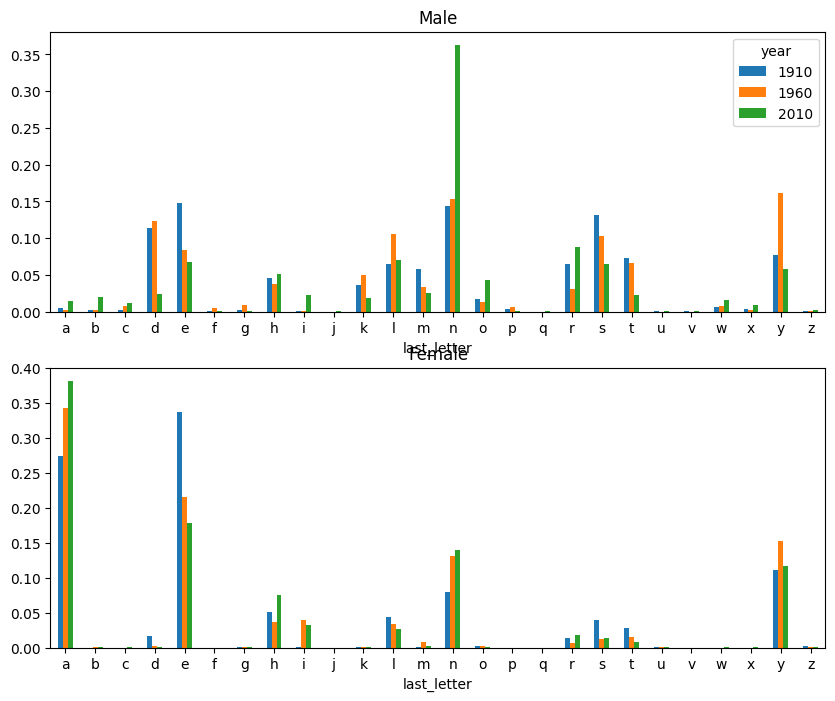

In [ ]:
fig, axes = plt.subplots(2, 1, figsize=(10, 8))
letter_prop["M"].plot(kind="bar", rot=0, ax=axes[0], title="Male")
letter_prop["F"].plot(kind="bar", rot=0, ax=axes[1], title="Female", legend=False)
plt.savefig("last_letter_female.png")


Nhận xét :

* Ở con trai, tên kết thúc bằng chữ “n” có sự tăng trưởng rõ rệt qua các năm.

* Ở con gái, sự phân bố chữ cái cuối đồng đều hơn, tuy nhiên có xu hướng thiên về các chữ “a”.

Kết luận:

* Ở con trai, sự gia tăng mạnh của các tên kết thúc bằng chữ “n” (như Aiden, Ethan, Benjamin, Mason) thể hiện xu hướng đặt tên hiện đại, mạnh mẽ và có âm cuối dứt khoát.

* Ở con gái, các tên kết thúc bằng chữ “a” ngày càng phổ biến, phản ánh thị hiếu ưa chuộng sự mềm mại, nữ tính trong cách đặt tên (Emma, Olivia, Sophia, Isabella).


Phân tích chi tiết hơn cho tên con trai

Để quan sát rõ xu hướng thay đổi của một số chữ cái cụ thể, ta tính tỷ lệ (%) của mỗi chữ cái cuối trong từng năm, và chỉ lấy dữ liệu của con trai:

In [ ]:
#tính tỷ lệ (%) mỗi chữ cái cuối trong tổng số sinh của từng năm và giới tính.
letter_prop = table / table.sum()
#Chọn các chữ cái cuối cần theo dõi (chỉ lấy con trai)
dny_ts = letter_prop.loc[["d", "n", "y"], "M"].T
dny_ts.head()

last_letter,d,n,y
year,,,
1880,0.083055,0.153213,0.075760
1881,0.083247,0.153214,0.077451
1882,0.085340,0.149560,0.077537
1883,0.084066,0.151646,0.079144
1884,0.086120,0.149915,0.080405


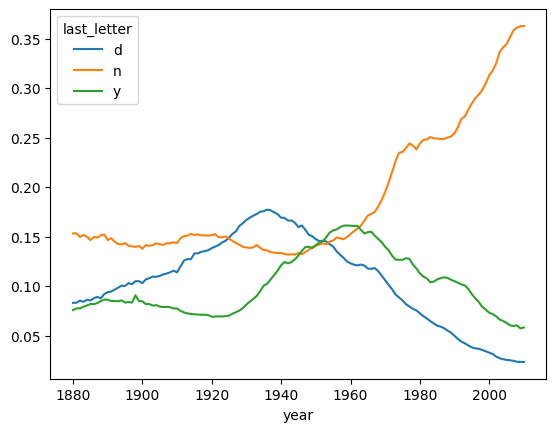

In [ ]:
dny_ts.plot()
plt.savefig("dny_ts.png")

Biểu đồ cho thấy:

* Tên kết thúc bằng “n” ngày càng phổ biến mạnh mẽ kể từ thập niên 1960, đồng thời tên kết thúc bằng “d” và “y” lại giảm rõ rệt.

* Điều này phản ánh sự chuyển dịch trong phong cách đặt tên:

  * Các tên hiện đại như Aiden, Ethan, Benjamin (kết thúc bằng “n”) dần chiếm ưu thế.

  * Trong khi các tên truyền thống như David, Larry, Harry (kết thúc bằng “d”, “y”) ngày càng ít được sử dụng.

### Sau khi đã quan sát sự thay đổi trong xu hướng đặt tên theo chữ cái cuối, một hiện tượng thú vị khác được phát hiện trong dữ liệu:
Liệu có tồn tại những tên vốn phổ biến cho con trai nhưng sau này lại được dùng chủ yếu cho con gái (hoặc ngược lại)?
Nếu có, sự chuyển dịch này diễn ra vào giai đoạn nào và với tốc độ ra sao?

Ta chọn các tên có chứa chuỗi "Lesl" (bao gồm Leslie, Lesley, Leslee…) để khảo sát hiện tượng này:

In [ ]:
all_names = pd.Series(top1000["name"].unique())
lesley_like = all_names[all_names.str.contains("Lesl")]
lesley_like

,0
654,Leslie
2307,Lesley
4257,Leslee
4725,Lesli
6096,Lesly


Sau đó lọc dữ liệu theo những tên trên và tính tổng số ca sinh:

In [ ]:
filtered = top1000[top1000["name"].isin(lesley_like)]
filtered.groupby("name")["births"].sum()


,births
name,
Leslee,993
Lesley,35009
Lesli,929
Leslie,370429
Lesly,10067


Tiếp theo, tổng hợp số lượng sinh theo giới tính và năm, rồi tính tỷ lệ (%) mỗi giới trong từng năm:

In [ ]:
table = filtered.pivot_table("births", index="year", columns="sex", aggfunc="sum")
table = table.div(table.sum(axis="columns"), axis="index")
table.head()

sex,F,M
year,,
1880,0.091954,0.908046
1881,0.106796,0.893204
1882,0.065693,0.934307
1883,0.053030,0.946970
1884,0.107143,0.892857


Cuối cùng, vẽ biểu đồ thể hiện sự thay đổi theo thời gian:

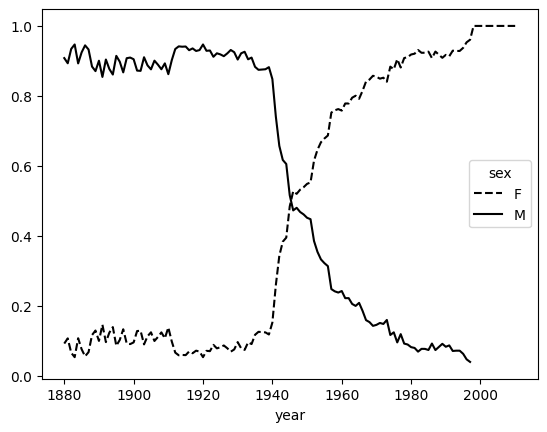

In [ ]:
table.plot(style={"M": "k-", "F": "k--"})
plt.savefig("lesley.png")

Biểu đồ cho thấy:

Trong những năm đầu thế kỷ 20, các biến thể của “Lesl” (như Leslie, Lesley) được dùng chủ yếu cho con trai.

* Tuy nhiên, kể từ thập niên 1940 trở đi, tỷ lệ sử dụng cho con gái bắt đầu tăng nhanh, và đến giai đoạn 1960–1980, tên này trở thành tên nữ phổ biến hơn.

* Sự chuyển dịch này thể hiện một điểm ngoặt rõ rệt trong quan niệm về tên gọi và giới tính tại Hoa Kỳ.

Kết luận

* Tên “Leslie” và các biến thể tương tự là ví dụ điển hình cho quá trình trung tính hóa giới tính trong tên gọi.
* Hiện tượng này có thể xuất phát từ:

  * Ảnh hưởng của văn hóa đại chúng, nơi tên “Leslie” xuất hiện nhiều trong phim ảnh và âm nhạc gắn liền với hình ảnh nữ tính.

  * Xu hướng xã hội cởi mở hơn với các tên phi giới tính, phản ánh thay đổi trong nhận thức về bình đẳng giới.

Từ đó có thể thấy, việc đặt tên không chỉ là lựa chọn ngôn ngữ, mà còn là biểu hiện của sự thay đổi trong tư duy văn hóa và xã hội theo thời gian.

# 4 Kết luận


Qua phân tích từ dữ liệu lịch sử về tên trẻ em tại Hoa Kỳ giai đoạn 1880–2010, có thể rút ra các kết luận tổng hợp sau:

  1. Thay đổi về số lượng sinh theo giới tính

Từ 1880 đến đầu thế kỷ 20, số trẻ nữ sinh ra cao hơn trẻ nam; tuy nhiên sau giai đoạn 1950, trẻ nam lại chiếm ưu thế.
Điều này phản ánh sự ổn định và chuẩn hóa trong thống kê dân số, cũng như quy mô dân số Mỹ ngày càng tăng.

  2. Sự thay đổi trong xu hướng đặt tên

Những cái tên từng cực kỳ phổ biến như John, Mary, Harry, Marilyn đã giảm mạnh về mức độ phổ biến theo thời gian.
Điều đó cho thấy người Mỹ không còn tập trung vào một số tên truyền thống, mà đa dạng hóa lựa chọn tên cho con cái — phản ánh sự thay đổi văn hóa và cá tính hóa trong xã hội hiện đại.

  3. Mức độ đa dạng trong đặt tên ngày càng tăng

Phân tích tỉ lệ sinh đại diện bởi 1000 tên phổ biến nhất cho thấy xu hướng giảm mạnh qua các thập niên, tức là nhiều tên mới xuất hiện hơn.
Cụ thể:

Năm 1900, chỉ cần ~25 tên phổ biến nhất đã chiếm 50% tổng số ca sinh.

Nhưng đến năm 2010, cần đến hơn 100 tên mới đạt cùng tỉ lệ đó.
⟶ Chứng tỏ mức độ đa dạng trong việc đặt tên tăng lên rõ rệt, thể hiện sự cá nhân hóa và sáng tạo trong văn hóa đặt tên.

  4. Cách kết thúc tên phản ánh xu hướng thời đại

Phân tích chữ cái cuối của tên cho thấy:

Tên con trai kết thúc bằng “n” (như Ethan, Aiden, Benjamin) tăng mạnh sau thập niên 1960.

Trong khi đó, các tên kết thúc bằng “d” hoặc “y” (David, Larry, Harry) giảm dần.
Điều này thể hiện sự chuyển dịch về phong cách ngôn ngữ, hướng tới các âm tiết mềm mại, hiện đại hơn — phù hợp với thị hiếu đương đại.

  5. Sự chuyển dịch giới tính trong tên gọi

Một số tên vốn dành cho con trai (như Leslie, Lesley) dần trở thành tên con gái kể từ sau năm 1940.
Hiện tượng này minh chứng cho sự thay đổi trong quan niệm giới tính, khi xã hội Mỹ dần cởi mở và bình đẳng hơn trong việc đặt tên, cho phép tên mang tính trung tính về giới.